# ECE1508: Deep Generative Models -- SUM25
## Assignment 3: Implicit Methods for Data Generation
### Programming Part
This assignment reviews implicit generation methods. We mainly focus on the VAE and diffusion models. Our goal os to implement some basic forms of these architectures to get a better understanding.

For each task, some explanations have been given and some starter code has been provided. Please complete the provided code and report your observations and conclusions for each part in the provided markdown. For submission, please pay attention to the instructions. Failure to following the instructions can lead to mark deduction.

Let's start with loading necessary libraries. And defining the `device`.

In [ ]:
import torch, torchvision
from torch.utils.data import TensorDataset, DataLoader, Subset, random_split
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as transforms
from torchvision.datasets import FashionMNIST, MNIST
import matplotlib.pyplot as plt
from tqdm import tqdm


import numpy as np
import random
import math

# select a device that we want to shift the process on: cuda, cpu, mps
if torch.backends.mps.is_built():
    device = "mps"
elif torch.backends.cuda.is_built():
    device = "cuda"
else:
    device = "cpu"

## Programming Question 1: Vector-Quantized VAE

### General Overview
In this assignment, we intend to train a vector-quantized VAE. We discussed this architecture in the course in some detail. In this assignment, we train this model to sample from the `FashionMNIST` dataset. The architecture consists of three components:

* An AE which encodes the data into the latent space and takes it back.
* A Quantizer that quantizes the latent space using a codebook.
* An AR model that learns the latent distribution.

In the sequel, we implement this architecture step by step.

### Building the AE
The encoder of the AE is a simple CNN with three convolutional layers. The following architecture is suggested but you are welcome to modify it
* each hidden convolution layer has 32 channels
* each hidden convolution layer is followed by pooling with stride 2
* each hidden convolution layer is activated by ReLU
* last convolution layer is not activated and has 64 channels

You may use batch normalization if you wish.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, in_channels=1, hidden_channels=32, embedding_dim=64):
        '''
        in_channels is 1 for FashionMNIST
        embedding_dim = number of output channels
        '''
        super().__init__()
        # COMPLETE
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, 3, padding=1),  # 28×28 → 28×28
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                         # 28×28 → 14×14

            nn.Conv2d(hidden_channels, hidden_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                         # 14×14 → 7×7

            nn.Conv2d(hidden_channels, embedding_dim, 3, padding=1)  # 7×7, no activation
        )

    def forward(self, x):
        # COMPLETE
        return self.features(x)          # (B, 64, 7, 7)


Now, we implement the decoder. The suggestion is to reverse the architecture of the encoder. You may use `nn.ConvTranspose2d` if you wish.

In [ ]:
class Decoder(nn.Module):
    def __init__(self, embedding_dim=64, hidden_channels=32, out_channels=1):
        # COMPLETE
        super().__init__()
        self.recon = nn.Sequential(
            nn.ConvTranspose2d(embedding_dim, hidden_channels, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(hidden_channels, hidden_channels,
                               4, stride=2, padding=1),            # 7×7 → 14×14
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(hidden_channels, out_channels,
                               4, stride=2, padding=1),            # 14×14 → 28×28
            nn.Sigmoid()                                           # pixel range [0,1], stride=2 since in encoder, maxpool 2
        )

    def forward(self, x):
        # COMPLETE
        return self.recon(x)

### Building the Vector Quantizer
We now write down the VQ block. The quantizer makes a codebook (learnable) of `num_embeddings` codewords each of size `embedding_dim` which is the size of the each output map of the encoder. It then performs the following:

1. takes the output of the encoder and treats each channel of it as a vector $u$
2. finds the codeword that is closest to this vector and replaces it in $z$
3. for training it passes $$z_{\mathrm{train}} = u - \mathrm{sg} (z-u)$$ this provides better gradients
4. computes loss as $$R = \| \mathrm{sg} (z) - u \|^2 + \text{weight} \| \mathrm{sg} (u) - z \|^2 $$ where weight is a number between 0 and 1. This way it provides better gradients for training. You have also seen it in Written Question 4.


In [ ]:
class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_loss_weight):
        '''
        num_embeddings = codebook size
        embedding_dim = dimension of each map at latent
        commitment_loss_weight = a weight for combining loss; typically between 0 and 1
        '''
        super().__init__()
        self.embedding_dim = embedding_dim # COMPLETE
        self.num_embeddings = num_embeddings # COMPLETE
        self.commitment_loss_weight = commitment_loss_weight # COMPLETE

        # Use nn.Embedding to build a codebook
        self.codebook = nn.Embedding(num_embeddings, embedding_dim) # COMPLETE

    def forward(self, u):
        ''''
        u = continuous encoder output, i.e., latent before quantization
        '''
        B, D, H, W = u.shape # batch, dim of latent z,

        # Format the shape
        u_perm = u.permute(0, 2, 3, 1).contiguous()

        # Flatten each map into a vector (u_i)
        flat_u = u_perm.view(-1, D)         # COMPLETE

        # Compute distances to codebook vectors: ||u_i - e_k||^2
        codebook = self.codebook.weight
        u_sq   = (flat_u ** 2).sum(dim=1, keepdim=True)      # (BHW, 1)
        e_sq   = (codebook ** 2).sum(dim=1)                  # (K,)
        distances = u_sq + e_sq - 2 * flat_u @ codebook.t() # COMPLETE

        # Find nearest codewords
        encoding_indices = distances.argmin(dim=1)           # (BHW,) # COMPLETE

        # Replace the latent with the codeword (discrete latent now)
        z = codebook[encoding_indices]   # COMPLETE

        # Convert back to original shape
        #z = z.view(B, H, W, D).permute(0, 3, 1, 2).contiguous()
        z = z.view(B, H, W, D)
        z = z.permute(0, 3, 1, 2).contiguous()

        # For training we use the "straight-through estimator"
        # This provides us better gradients
        z_train = u + (z - u).detach() # COMPLETE

        ## Losses
        codebook_loss = F.mse_loss(z, u.detach())          # ‖sg(u) - z‖² # COMPLETE
        commitment_loss = F.mse_loss(u, z.detach())          # ‖u - sg(z)‖² # COMPLETE

        # combine the two losses using self.commitment_loss_weight
        loss = codebook_loss + self.commitment_loss_weight * commitment_loss # COMPLETE

        return {
            'u': u,                    # real-valued encoder output
            'z': z_train,              # quantized version + error used by decoder during training
            'vq_loss': loss,           # VQ loss
            'encoding_indices': encoding_indices.view(u.shape[0], u.shape[2], u.shape[3]),
            #'encoding_indices': encoding_indices.view(B, H, W)
        }


### Training Loop VQ-VAE
We now train this architecture:
$$
\text{Input} \rightarrow \text{Encoder} \rightarrow u \rightarrow \text{VQ} \rightarrow z \rightarrow \text{Decoder} \rightarrow \text{Input Recovery}
$$

We first write the `train_VQVAE` function which takes the components and trains the AE. Note that the loss in this case, is the summation of the quantization and reconstruction losses.

In [ ]:
def train_VQVAE(encoder, decoder, vq_layer, num_epochs, train_loader, optimizer):
    for epoch in range(num_epochs):

        # put to train mode
        encoder.train()
        decoder.train()
        vq_layer.train()

        # initiate variables
        total_loss = 0
        recon_loss_total = 0
        vq_loss_total = 0

        # train loop
        for images, _ in train_loader:
            images = images.to(device)

            # Encode
            u = encoder(images)      # COMPLETE

            # Vector quantization
            vq_out = vq_layer(u) # COMPLETE
            # take the quantized output
            z = vq_out['z'] # COMPLETE
            # compute quantization loss
            vq_loss = vq_out['vq_loss'] # COMPLETE

            # Decode
            x_recon = decoder(z)  # COMPLETE

            # Compute reconstruction loss
            # COMPLETE
            recon_loss = F.mse_loss(x_recon, images)

            # Add quantization loss to reconstruction loss
            loss = recon_loss + vq_loss # COMPLETE

            # Backpropagate and optimize
            # COMPLETE
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Update losses
            total_loss += loss.item()
            recon_loss_total += recon_loss.item()
            vq_loss_total += vq_loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}]  "
            f"Total Loss: {total_loss:.3f}  "
            f"Reconstruction Loss: {recon_loss_total:.3f}  "
            f"Quantization Loss: {vq_loss_total:.3f}")


### Load Data and Train
We now instantiate data and model

In [ ]:
from torchvision import datasets, transforms

In [ ]:
# set the dimensions and weights
embedding_dim = 64
num_embeddings = 128
commitment_cost = 0.25
lr = 1e-3
num_epochs = 20

## We load Fashion MNIST
# We perform some required transform
transform = transforms.Compose([transforms.ToTensor()])                   # range [0,1]
# We then load the dataset
train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)# COMPLETE
# and build a train loader
# batch_size          = 128
train_loader  = DataLoader(train_dataset,batch_size=64,shuffle=True) # COMPLETE

# Instantiate an encoder, VQ and decoder and move them to device
encoder = Encoder().to(device)  # COMPLETE
vq_layer = VectorQuantizer(num_embeddings,embedding_dim,commitment_cost).to(device) # COMPLETE# COMPLETE
decoder = Decoder().to(device)  # COMPLETE

# list the parameters and pass them to Adam optimizer
params = list(encoder.parameters()) + list(decoder.parameters()) + list(vq_layer.parameters()) # COMPLETE
optimizer = torch.optim.Adam(params, lr=lr)


and train

In [ ]:
# COMPLETE using train_VQVAE
train_VQVAE(encoder, decoder, vq_layer, num_epochs, train_loader,optimizer)

Epoch [1/20]  Total Loss: 144.736  Reconstruction Loss: 56.128  Quantization Loss: 88.608
Epoch [2/20]  Total Loss: 117.401  Reconstruction Loss: 26.931  Quantization Loss: 90.470
Epoch [3/20]  Total Loss: 68.787  Reconstruction Loss: 20.660  Quantization Loss: 48.127
Epoch [4/20]  Total Loss: 51.154  Reconstruction Loss: 17.468  Quantization Loss: 33.686
Epoch [5/20]  Total Loss: 52.118  Reconstruction Loss: 17.064  Quantization Loss: 35.054
Epoch [6/20]  Total Loss: 52.126  Reconstruction Loss: 16.797  Quantization Loss: 35.329
Epoch [7/20]  Total Loss: 52.189  Reconstruction Loss: 16.567  Quantization Loss: 35.622
Epoch [8/20]  Total Loss: 52.391  Reconstruction Loss: 16.420  Quantization Loss: 35.971
Epoch [9/20]  Total Loss: 52.609  Reconstruction Loss: 16.274  Quantization Loss: 36.334
Epoch [10/20]  Total Loss: 50.574  Reconstruction Loss: 15.949  Quantization Loss: 34.625
Epoch [11/20]  Total Loss: 35.072  Reconstruction Loss: 13.778  Quantization Loss: 21.294
Epoch [12/20]  To

### Check Reconstruction
Let us now take a look at reconstruction.

In [ ]:
def show_reconstructions(loader, n=8):
    encoder.eval(); decoder.eval(); vq_layer.eval()
    with torch.no_grad():
        test_imgs, _ = next(iter(loader))
        test_imgs = test_imgs.to(device)
        n = min(n, test_imgs.size(0))
        test_imgs = test_imgs[:n]

        u = encoder(test_imgs)
        vq_out = vq_layer(u)
        z = vq_out['z']
        x_recon = decoder(z)

        imgs = torch.cat([test_imgs, x_recon], dim=0).cpu()

        fig, axes = plt.subplots(2, n, figsize=(1.5*n, 3))
        for i in range(n):
            axes[0, i].imshow(imgs[i, 0], cmap='gray', interpolation='nearest', vmin=0, vmax=1)
            axes[0, i].axis('off')
            axes[1, i].imshow(imgs[i + n, 0], cmap='gray', interpolation='nearest', vmin=0, vmax=1)
            axes[1, i].axis('off')
        axes[0, 0].set_ylabel("Original")
        axes[1, 0].set_ylabel("Reconstruction")
        plt.tight_layout()
        plt.show()

Let's take a look then

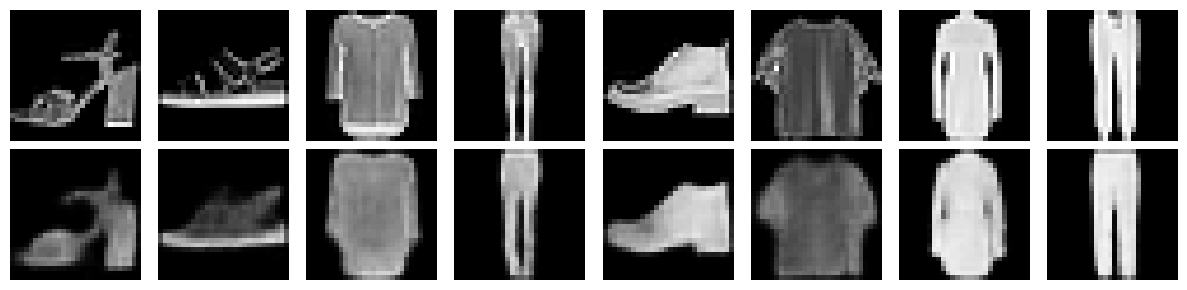

In [ ]:
# COMPLETE using show_reconstructions
show_reconstructions(train_loader)

### Question: _What do you observe? Do we really do Variational AE?_

the reconstruction is able to capture the coarse outline of fashion-MNIST items, but loss some details.

VQ-VAE is not a real variational AE. Instead of maximizing ELBO (push decoded sample p(x|z) to match input x, and min KL divergence between encode's posterior q(z|x) to p(z)), it learns a discrete latent codebook via nearest-neighbour vector-quantisation and is trained with a reconstruction + codebook/commitment loss instead.


### Learning Latent Distribution
To learn the latent distribution, we use PixelCNN. Since we already have implemented this architecture, the code is given here, and you may directly use it. Feel free to modify it if you wish.

In [ ]:
# This is a masked Convolution <No need to Complete>
class MaskedConv2d(nn.Conv2d):
    def __init__(self, in_channels, out_channels, kernel_size, mask_type='A', **kwargs):
        super().__init__(in_channels, out_channels, kernel_size, padding=kernel_size//2, **kwargs)
        self.register_buffer("mask", torch.ones_like(self.weight))

        yc, xc = kernel_size // 2, kernel_size // 2

        self.mask[:, :, yc+1:, :] = 0
        self.mask[:, :, yc, xc+1:] = 0
        if mask_type == 'A':
            self.mask[:, :, yc, xc] = 0  # zero center for first layer

    def forward(self, x):
        self.weight.data *= self.mask
        return super().forward(x)

# and this is a simple PixelCNN <No need to Complete>

class PixelCNN(nn.Module):
    def __init__(self, num_embeddings, hidden_channels=64, n_layers=7):
        super().__init__()
        layers = []
        layers.append(MaskedConv2d(1, hidden_channels, kernel_size=7, mask_type='A'))

        for _ in range(n_layers - 2):
            layers.append(MaskedConv2d(hidden_channels, hidden_channels, kernel_size=3, mask_type='B'))
            layers.append(nn.ReLU())

        layers.append(nn.Conv2d(hidden_channels, num_embeddings, kernel_size=1))  # logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):  # x: (B, 1, H, W) of integer indices
        return self.net(x)


We now train this pixelCNN to learn the latent distribution. To this end, we first write a function that takes the dataloader and returns the quantized latent representation of them. This will build our dataset on which we train the PixelCNN.

In [ ]:
def encode_dataset(encoder, vq_layer, dataloader):
    all_indices = []
    encoder.eval()
    vq_layer.eval()

    with torch.no_grad():
        for x, _ in dataloader:
            # COMPLETE
            x = x.to(device)
            u = encoder(x)
            vq_out = vq_layer(u)
            indices = vq_out['encoding_indices'] # COMPLETE

            # append the quantization
            all_indices.append(indices)

    # Concatenate to get full size
    all_indices = torch.cat(all_indices, dim=0)

    # Add channel dimension
    all_indices = all_indices.unsqueeze(1)

    return TensorDataset(all_indices)


We next write a training loop for PixelCNN which trains the PixelCNN on the encoded dataset.

In [ ]:
def train_PixelCNN(pixelcnn, optimizer, index_loader, num_epochs):
    '''
    index_loader = encoded dataset
    '''
    K = num_embeddings
    for epoch in range(num_epochs):
        pixelcnn.train()
        total_loss = 0

        for (indices,) in index_loader:
            # COMPLETE
            indices = indices.to(device).long()                    # targets in [0..K-1]
            inp = (indices.float() + 1.0) / K                      # 1..K -> (0,1], PAD=0
            logits = pixelcnn(inp)                                 # (B,K,H,W)
            loss = F.cross_entropy(logits.view(-1, num_embeddings), indices.view(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"PixelCNN Epoch {epoch+1}, Loss: {total_loss:.4f}")

Now let's instantiate and train.

In [ ]:
# Model and optimizer
pixelcnn = PixelCNN(num_embeddings).to(device) # COMPLETE
optimizer = torch.optim.Adam(pixelcnn.parameters(), lr=1e-3) # COMPLETE using Adam

# encoded dataset
index_dataset = encode_dataset(encoder, vq_layer, train_loader) # COMPLETE
index_loader = DataLoader(index_dataset, batch_size=64, shuffle=True)

# etc
num_epochs = 50

# COMPLETE using train_PixelCNN
train_PixelCNN(pixelcnn, optimizer, index_loader, num_epochs)

PixelCNN Epoch 1, Loss: 2008.1149
PixelCNN Epoch 2, Loss: 1621.2777
PixelCNN Epoch 3, Loss: 1493.9741
PixelCNN Epoch 4, Loss: 1396.1135
PixelCNN Epoch 5, Loss: 1320.7937
PixelCNN Epoch 6, Loss: 1261.9334
PixelCNN Epoch 7, Loss: 1211.3820
PixelCNN Epoch 8, Loss: 1167.6597
PixelCNN Epoch 9, Loss: 1131.0255
PixelCNN Epoch 10, Loss: 1098.4860
PixelCNN Epoch 11, Loss: 1070.6125
PixelCNN Epoch 12, Loss: 1046.6860
PixelCNN Epoch 13, Loss: 1023.3105
PixelCNN Epoch 14, Loss: 1001.1931
PixelCNN Epoch 15, Loss: 980.6694
PixelCNN Epoch 16, Loss: 960.6393
PixelCNN Epoch 17, Loss: 941.8766
PixelCNN Epoch 18, Loss: 926.4897
PixelCNN Epoch 19, Loss: 910.8891
PixelCNN Epoch 20, Loss: 896.3329
PixelCNN Epoch 21, Loss: 882.8230
PixelCNN Epoch 22, Loss: 869.6531
PixelCNN Epoch 23, Loss: 857.3351
PixelCNN Epoch 24, Loss: 845.1296
PixelCNN Epoch 25, Loss: 833.3997
PixelCNN Epoch 26, Loss: 823.9643
PixelCNN Epoch 27, Loss: 813.2737
PixelCNN Epoch 28, Loss: 805.0795
PixelCNN Epoch 29, Loss: 796.4588
PixelCNN 

### Sampling Latent
We now write a simple function to sample from the latent distribution using our trained AR model.

In [ ]:
def sample_pixelcnn(pixelcnn, shape, temperature=1.0):
    '''
    shape = the desired shape that matches the decoder input
    temperature = for Softmax while sampling
    '''
    pixelcnn.eval()
    samples = torch.zeros(shape, dtype=torch.long).to(device)      # index canvas (returned)
    cond    = torch.zeros_like(samples, dtype=torch.float32)       # float canvas for PixelCNN

    with torch.no_grad():
        # write the AR sampling
        for i in range(shape[2]):
            for j in range(shape[3]):
                logits = pixelcnn(cond)                            # COMPLETE
                probs  = F.softmax(logits[:, :, i, j] / temperature, dim=-1)  # COMPLETE
                next_idx = torch.multinomial(probs, num_samples=1).squeeze(1)
                samples[:, 0, i, j] = next_idx                     # COMPLETE
                # update conditioning canvas with normalized scalar value
                cond[:, 0, i, j] = (next_idx.float() + 1.0) / num_embeddings

    return samples


We also write a decoding function which uses the trained decoder to decode a latent sample.

In [ ]:
def decode_indices(samples, vq_layer, decoder):
    # take corresponding codewords from the codebook
    codewords = vq_layer.codebook.weight[samples.squeeze(1)] # COMPLETE
    # put it in the right shape
    z = codewords.permute(0, 3, 1, 2).contiguous()
    return decoder(z)

### Generation
We now sample the latent via the AR model and look at the decoded version.

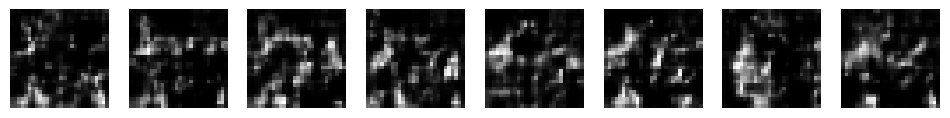

In [ ]:
# sample 8 latent samples and decode
samples = sample_pixelcnn(pixelcnn, shape=(8, 1, 7, 7)) # COMPLETE
decoded_imgs = decode_indices(samples, vq_layer, decoder).cpu().detach() # COMPLETE

# visualize
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axes[i].imshow(decoded_imgs[i][0], cmap='gray')
    axes[i].axis('off')
plt.show()

### Question: _How is the quality? Does it match your expectation? How can we improve the quality?

the generated samples have poor quality.

To improve
- train pixelCNN for more epoches
- sample with lower temperature
- use a more complex pixelCNN structure



## Programming Question 2: Diffusion Score Matching
In this assignment we try to build the simplest possible diffusion model and train it on the subset of MNIST dataset that include only digit 8. The main purpose is to review what we have learned about diffusion and its connection to data generation. Our model consists of a simple score network which is trained using the diffusion score matching idea: _add noise to samples and estimate their score using the noise term._ We train this network on MNIST and then use it to generate samples by a simple reverse SDE.

### Building the Score Net
Our score net is a basic CNN with 8 layers. The number of channels change in the following order
$$
1 (\text{MNIST}) \mapsto 32 \mapsto 64 \mapsto 128 \mapsto 256 \mapsto 128 \mapsto 64 \mapsto 32 \mapsto 1
$$
each layer uses batch normalization. We activate each layer by $\mathrm{SiLU}$ function.

To include the noise standard deviation $\sigma$, we use the following trick: we first embed the noise standard deviation via the following positional encoding:
1. choose an even embedding dimension $d$
2. for $i = 0,1,\ldots, d/2-1$ find the following frequencies
$$
\omega_i = 10000^{- \frac{i}{d/2-1} }
$$
3. compute the following embedding vector
$$
\bold{e} (\sigma) = [ \sin (\omega_0 \log \sigma ), \sin (\omega_1 \log \sigma ), \ldots, \sin (\omega_{d/2-1} \log \sigma ),
\cos (\omega_0 \log \sigma ), \cos (\omega_1\log \sigma ), \ldots, \cos (\omega_{d/2-1} \log \sigma )
]
$$

Then, in each convolutional layer, we add the impact of noise standard deviation by projecting its embedding $\bold{e} (\sigma)$ via a linear layer and adding it to the output of convolution _after batch normalization_ and _before activation._ The following code implement this score net.

In [ ]:
class ScoreNet(nn.Module):
    def __init__(self, embed_dim=32):
        '''
        embed_dim = size of noise embedding
        '''
        super().__init__()

        self.embed_dim = embed_dim

        # Convolutional layers with BatchNorm
        # COMPLETE
        channels = [1, 32, 64, 128, 256, 128, 64, 32, 1]
        self.convs = nn.ModuleList([
            nn.Conv2d(channels[i], channels[i+1], kernel_size=3, padding=1)
            for i in range(len(channels) - 1)
        ])

        # BN and FiLM for hidden layers only (exclude last)
        self.bns = nn.ModuleList([
            nn.BatchNorm2d(channels[i+1])
            for i in range(len(channels) - 2)  # 7 entries
        ])
        self.noise_mlps = nn.ModuleList([
            nn.Linear(embed_dim, channels[i+1])
            for i in range(len(channels) - 2)  # 7 entries
        ])

        self.act = nn.SiLU()

    def _get_embedding(self, log_sigma, embedding_dim):
        half_dim = embedding_dim // 2

        # compute frequencies omega
        freq = torch.exp(torch.linspace(0, -math.log(10000), steps=half_dim, device=log_sigma.device))
        emb = log_sigma[:, None] * freq[None, :] # (B, half) # COMPLETE

        # get the positional encoding
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb



    def forward(self, x, sigma):
        B, C, H, W = x.shape

        # embed the noise
        log_sigma = torch.log(sigma.clamp(min=1e-8)).view(B)
        noise_emb = self._get_embedding(log_sigma, self.embed_dim)  # (B,d) # COMPLETE

        # pass through conv and normalize
        # COMPLETE
        h = x
        # hidden blocks: Conv → BN → +FiLM → SiLU
        for conv, bn, mlp in zip(self.convs[:-1], self.bns, self.noise_mlps):
            h = conv(h)
            h = bn(h)
            beta = mlp(noise_emb).view(B, bn.num_features, 1, 1)
            h = h + beta
            h = self.act(h)

        # final layer: linear (no BN/FiLM/activation)
        h = self.convs[-1](h)
        return h


### Defining DSM Loss
We next define the loss of diffusion score matching. Here, we consider direct estimation of the score given by the noise term.

In [ ]:
def dsm_loss(score_net, x, device, sigma_min=1e-6, sigma_max=1.0):
    '''
    sigma_min and sigma_max are the range of sigma we train the score net on
    '''
    B = x.shape[0]

    # Sample random noise levels
    log_sigma = torch.rand(B, 1, 1, 1, device=device) * \
        (np.log(sigma_max) - np.log(sigma_min)) + np.log(sigma_min)
    sigma = torch.exp(log_sigma)

    # Add noise
    noise = torch.randn_like(x) * sigma   # COMPLETE gaussian noise
    x_noisy = x + noise # COMPLETE

    # Predict score by Score Net
    score_pred = score_net(x_noisy, sigma)  # COMPLETE

    # Find the score estimate from noise
    target = -noise / (sigma ** 2)     # COMPLETE -(x_noisy - x)/σ²

    # for training stability, we scale thr loss with sigma^2
    weights = sigma ** 2
    loss = torch.mean(weights * (score_pred - target) ** 2)

    return loss

### Sampling Diffusion Process
We now sample the diffusion trajectory. In this trajectory, we consider the forward SDE as
$$
\mathrm{d} x_t = -\frac{1}{2} \beta_t \mathrm{d} t + \sqrt{\beta_t} \mathrm{d} B_t
$$
where here $\beta_t$ is a function of time. We consider a simple linear function:
$$
\beta_t = \beta_{\min} + (\beta_{\max}- \beta_{\min}) t
$$
for some minimum and maximum choice of $\beta$.

Note that we use the __reverse SDE__ to sample from data distribution. In our implementation, we approximate the eduation by breaking the time interval $t\in [10^{-6}, 1]$ into 1000 time steps, i.e., $\mathrm{d} t \approx 0.001$. You can increase the accuracy as you wish.


### Question: _Write down the reverse SDE._
COMPLETE
__Hint:__ When you build the reverse SDE pay attention to the sign of time difference $\mathrm{d} t$ when multiplied by drift term.

In [ ]:
# write the beta function
def beta_schedule(t, beta_min=0.1, beta_max=10.0):
    # Linearly increasing beta(t)
    # β(t) = β_min + (β_max − β_min) · t   ,  0≤t≤1
    return beta_min + (beta_max - beta_min) * t # COMPLETE

def cumulative_lambda(t, beta_min=0.1, beta_max=10.0):
    return beta_min * t + 0.5 * (beta_max - beta_min) * t * t


# write sampling function
@torch.no_grad()
def sample_from_model(score_net, shape, device, num_steps=1000):
    score_net.eval()

    # sample noise
    x = torch.randn(shape, device=device) # COMPLETE

    # specify time steps backward 1 -> 0
    t_steps = torch.linspace(1.0, 1e-6, num_steps, device=device)
    # t_steps = torch.randn(shape, device=device)# COMPLETE

    # start the trajectory
    for i in range(num_steps - 1):
        # time steps and dt
        t = t_steps[i] # COMPLETE
        t_next = t_steps[i+1]
        dt = t_next - t # COMPLETE

        # find beta_t
        beta_t = beta_schedule(t) # COMPLETE

        # compute noise standard deviation and give it along with x to score net for denoising
        lam_t  = cumulative_lambda(t)
        sigma = torch.sqrt(1.0 - torch.exp(-lam_t))
        sd_tensor = torch.full((shape[0], 1, 1, 1), sigma.item(), device=device)
        score = score_net(x, sd_tensor) # COMPLETE

        # use score to compute drift and diffusion coefficient of the reverse SDE
        drift = -0.5 * beta_t * x - beta_t * score  # COMPLETE
        diffusion = torch.sqrt(beta_t)     # COMPLETE

        # write the reverse SDE
        noise = torch.randn_like(x)
        x = x + drift * dt + diffusion * torch.sqrt(-dt) * noise # COMPLETE

        if (i+1) % 200 == 0 or i==0:
            print(f" Step {i+1}/{num_steps}, t={t:.4f}, noise SD={sigma:.2f}")

    return x


### Training DSM
We now train our score model on digit 8 images in MNIST. Let us first write the train function.

In [ ]:
def train_score_model(model, train_loader, device, num_epochs = 100):

    # Optimizer: for simplicity included in the function
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-6)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)


    # Let's visualize the output every couple of epochs
    sample_interval = 10
    losses = []

    # training loop
    for epoch in range(num_epochs):
        model.train()
        epoch_losses = []

        # for visualization
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')

        # batch computations visualized
        for _, (data, _) in enumerate(pbar):
            # COMPLETE
            data = data.to(device)
            loss = dsm_loss(model, data, device) # COMPLETE

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_losses.append(loss.item())

            # Update progress bar
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # schedule the learning rate
        scheduler.step()

        # Log epoch results
        avg_loss = np.mean(epoch_losses)
        losses.append(avg_loss)
        print(f'Epoch {epoch+1}: Loss = {avg_loss:.4f}, LR = {scheduler.get_last_lr()[0]:.6f}')

        # Generate samples every couple of epochs
        if (epoch + 1) % sample_interval == 0:
            print("Generating samples...")
            model.eval()

            # sample a batch of 6 images
            # COMPLETE
            with torch.no_grad():
                samples = sample_from_model(model,
                                            shape=(6, 1, 28, 28),
                                            device=device,
                                            num_steps=1000)

            # Normalize samples based on data range
            samples = samples.clamp(0.0, 1.0).cpu() # COMPLETE

            # Plot samples
            fig, axes = plt.subplots(1, 6, figsize=(12,2))
            for i, ax in enumerate(axes.flat):
                ax.imshow(samples[i, 0].cpu().numpy(), cmap='gray')
                ax.axis('off')
            plt.suptitle(f'Generated Samples - Epoch {epoch+1} (Loss: {avg_loss:.3f})')
            plt.tight_layout()
            plt.show()

        # Save checkpoint if you like
        if (epoch + 1) % 50 == 0:
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
                'losses': losses
            }
            torch.save(checkpoint, f'dsm_model_epoch_{epoch+1}.pt')
            print(f"Checkpoint saved: dsm_model_epoch_{epoch+1}.pt")

    # Final training curve
    plt.figure(figsize=(10, 6))
    plt.plot(losses)
    plt.title('DSM Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.grid(True)
    plt.show()

    return model, losses

### Train on MNIST
We now train it on MNIST and look at the result. First we instantiate the model and prepare dataloader.

In [ ]:
# Load MNIST
# COMPLETE
from torchvision import datasets, transforms
transform = transforms.Compose([
    transforms.ToTensor(),
])
full_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)

# Find indices of digit 8
digit_8_indices = [i for i, (_, label) in enumerate(full_dataset) if label == 8] # COMPLETE

# Create dataset
train_dataset = Subset(full_dataset, digit_8_indices)
train_loader = DataLoader(train_dataset,batch_size=128,shuffle=True,) # COMPLETE

model = ScoreNet().to(device) # COMPLETE
num_epochs = 100

100%|██████████| 9.91M/9.91M [00:00<00:00, 38.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.06MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.67MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.7MB/s]


and now we train

Epoch 1/100: 100%|██████████| 46/46 [00:01<00:00, 33.40it/s, loss=0.7144]


Epoch 1: Loss = 0.7763, LR = 0.000100


Epoch 2/100: 100%|██████████| 46/46 [00:01<00:00, 33.94it/s, loss=0.7645]


Epoch 2: Loss = 0.7694, LR = 0.000100


Epoch 3/100: 100%|██████████| 46/46 [00:01<00:00, 33.91it/s, loss=0.8106]


...

Epoch 8: Loss = 0.7502, LR = 0.000098


Epoch 9/100: 100%|██████████| 46/46 [00:01<00:00, 32.78it/s, loss=0.7072]


Epoch 9: Loss = 0.7451, LR = 0.000098


Epoch 10/100: 100%|██████████| 46/46 [00:01<00:00, 32.72it/s, loss=0.7546]


Epoch 10: Loss = 0.7456, LR = 0.000098
Generating samples...
 Step 1/1000, t=1.0000, noise SD=1.00
 Step 200/1000, t=0.8008, noise SD=0.98
 Step 400/1000, t=0.6006, noise SD=0.92
 Step 600/1000, t=0.4004, noise SD=0.75
 Step 800/1000, t=0.2002, noise SD=0.44


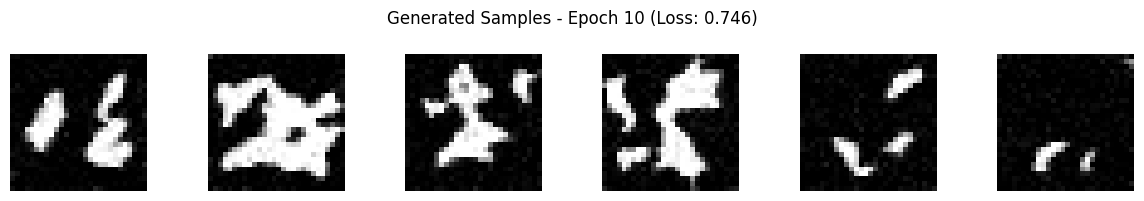

Epoch 11/100: 100%|██████████| 46/46 [00:01<00:00, 33.75it/s, loss=0.7104]


Epoch 11: Loss = 0.7460, LR = 0.000097


Epoch 12/100: 100%|██████████| 46/46 [00:01<00:00, 34.24it/s, loss=0.7400]


Epoch 12: Loss = 0.7384, LR = 0.000097


Epoch 13/100: 100%|██████████| 46/46 [00:01<00:00, 34.30it/s, loss=0.7723]


...

Epoch 18: Loss = 0.7281, LR = 0.000092


Epoch 19/100: 100%|██████████| 46/46 [00:01<00:00, 33.53it/s, loss=0.8125]


Epoch 19: Loss = 0.7253, LR = 0.000091


Epoch 20/100: 100%|██████████| 46/46 [00:01<00:00, 34.05it/s, loss=0.7212]


Epoch 20: Loss = 0.7177, LR = 0.000091
Generating samples...
 Step 1/1000, t=1.0000, noise SD=1.00
 Step 200/1000, t=0.8008, noise SD=0.98
 Step 400/1000, t=0.6006, noise SD=0.92
 Step 600/1000, t=0.4004, noise SD=0.75
 Step 800/1000, t=0.2002, noise SD=0.44


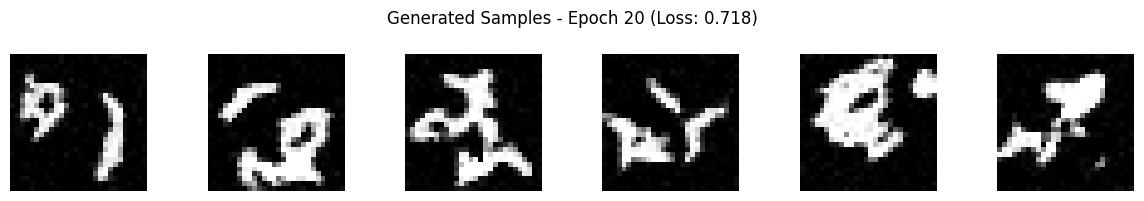

Epoch 21/100: 100%|██████████| 46/46 [00:01<00:00, 33.22it/s, loss=0.7003]


Epoch 21: Loss = 0.7214, LR = 0.000090


Epoch 22/100: 100%|██████████| 46/46 [00:01<00:00, 33.75it/s, loss=0.7446]


Epoch 22: Loss = 0.7271, LR = 0.000089


Epoch 23/100: 100%|██████████| 46/46 [00:01<00:00, 34.01it/s, loss=0.6478]


...

Epoch 28: Loss = 0.7158, LR = 0.000082


Epoch 29/100: 100%|██████████| 46/46 [00:01<00:00, 33.86it/s, loss=0.7076]


Epoch 29: Loss = 0.7142, LR = 0.000081


Epoch 30/100: 100%|██████████| 46/46 [00:01<00:00, 33.46it/s, loss=0.7877]


Epoch 30: Loss = 0.7112, LR = 0.000080
Generating samples...
 Step 1/1000, t=1.0000, noise SD=1.00
 Step 200/1000, t=0.8008, noise SD=0.98
 Step 400/1000, t=0.6006, noise SD=0.92
 Step 600/1000, t=0.4004, noise SD=0.75
 Step 800/1000, t=0.2002, noise SD=0.44


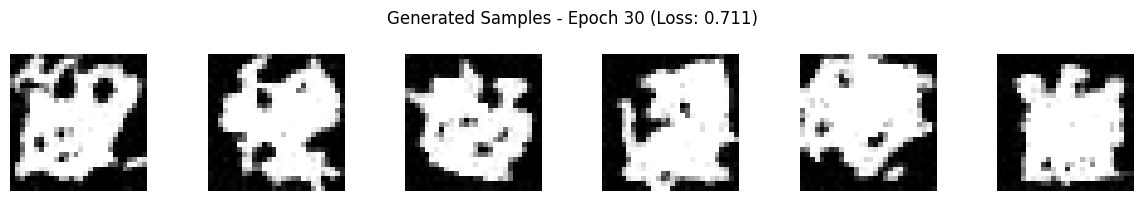

Epoch 31/100: 100%|██████████| 46/46 [00:01<00:00, 33.18it/s, loss=0.6759]


Epoch 31: Loss = 0.7036, LR = 0.000078


Epoch 32/100: 100%|██████████| 46/46 [00:01<00:00, 33.81it/s, loss=0.6692]


Epoch 32: Loss = 0.7047, LR = 0.000077


Epoch 33/100: 100%|██████████| 46/46 [00:01<00:00, 33.62it/s, loss=0.7215]


...

Epoch 38: Loss = 0.6999, LR = 0.000069


Epoch 39/100: 100%|██████████| 46/46 [00:01<00:00, 33.86it/s, loss=0.7070]


Epoch 39: Loss = 0.6911, LR = 0.000067


Epoch 40/100: 100%|██████████| 46/46 [00:01<00:00, 34.32it/s, loss=0.7164]


Epoch 40: Loss = 0.6951, LR = 0.000066
Generating samples...
 Step 1/1000, t=1.0000, noise SD=1.00
 Step 200/1000, t=0.8008, noise SD=0.98
 Step 400/1000, t=0.6006, noise SD=0.92
 Step 600/1000, t=0.4004, noise SD=0.75
 Step 800/1000, t=0.2002, noise SD=0.44


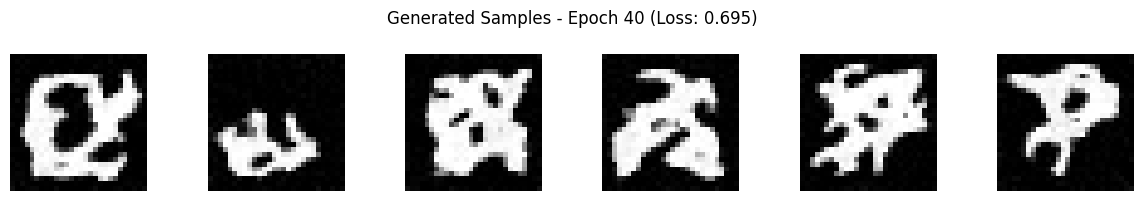

Epoch 41/100: 100%|██████████| 46/46 [00:01<00:00, 33.42it/s, loss=0.7092]


Epoch 41: Loss = 0.7053, LR = 0.000064


Epoch 42/100: 100%|██████████| 46/46 [00:01<00:00, 33.98it/s, loss=0.6684]


Epoch 42: Loss = 0.6862, LR = 0.000063


Epoch 43/100: 100%|██████████| 46/46 [00:01<00:00, 33.50it/s, loss=0.7289]


...

Epoch 48: Loss = 0.6888, LR = 0.000054


Epoch 49/100: 100%|██████████| 46/46 [00:01<00:00, 33.51it/s, loss=0.6798]


Epoch 49: Loss = 0.6977, LR = 0.000052


Epoch 50/100: 100%|██████████| 46/46 [00:01<00:00, 34.03it/s, loss=0.6918]


Epoch 50: Loss = 0.6941, LR = 0.000051
Generating samples...
 Step 1/1000, t=1.0000, noise SD=1.00
 Step 200/1000, t=0.8008, noise SD=0.98
 Step 400/1000, t=0.6006, noise SD=0.92
 Step 600/1000, t=0.4004, noise SD=0.75
 Step 800/1000, t=0.2002, noise SD=0.44


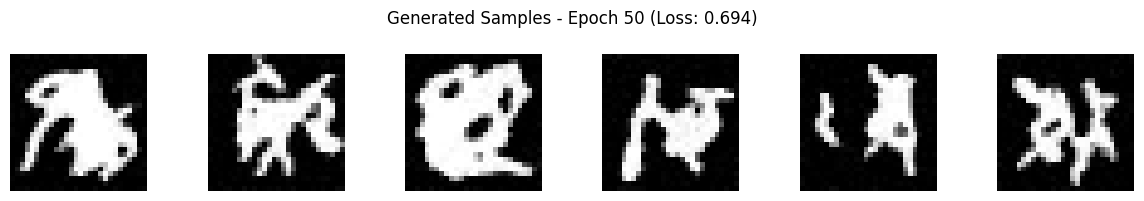

Checkpoint saved: dsm_model_epoch_50.pt


Epoch 51/100: 100%|██████████| 46/46 [00:01<00:00, 33.10it/s, loss=0.6586]


Epoch 51: Loss = 0.6958, LR = 0.000049


Epoch 52/100: 100%|██████████| 46/46 [00:01<00:00, 34.22it/s, loss=0.8092]


Epoch 52: Loss = 0.6943, LR = 0.000047


...

Epoch 58: Loss = 0.6880, LR = 0.000038


Epoch 59/100: 100%|██████████| 46/46 [00:01<00:00, 33.90it/s, loss=0.6111]


Epoch 59: Loss = 0.6847, LR = 0.000037


Epoch 60/100: 100%|██████████| 46/46 [00:01<00:00, 34.19it/s, loss=0.6946]


Epoch 60: Loss = 0.6792, LR = 0.000035
Generating samples...
 Step 1/1000, t=1.0000, noise SD=1.00
 Step 200/1000, t=0.8008, noise SD=0.98
 Step 400/1000, t=0.6006, noise SD=0.92
 Step 600/1000, t=0.4004, noise SD=0.75
 Step 800/1000, t=0.2002, noise SD=0.44


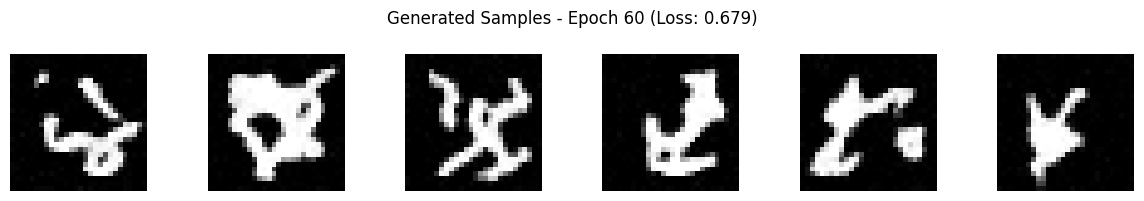

Epoch 61/100: 100%|██████████| 46/46 [00:01<00:00, 33.10it/s, loss=0.6770]


Epoch 61: Loss = 0.6886, LR = 0.000034


Epoch 62/100: 100%|██████████| 46/46 [00:01<00:00, 33.63it/s, loss=0.7429]


Epoch 62: Loss = 0.6884, LR = 0.000032


Epoch 63/100: 100%|██████████| 46/46 [00:01<00:00, 33.53it/s, loss=0.6513]


...

Epoch 68: Loss = 0.6889, LR = 0.000024


Epoch 69/100: 100%|██████████| 46/46 [00:01<00:00, 34.25it/s, loss=0.7407]


Epoch 69: Loss = 0.6866, LR = 0.000023


Epoch 70/100: 100%|██████████| 46/46 [00:01<00:00, 34.03it/s, loss=0.6486]


Epoch 70: Loss = 0.6893, LR = 0.000021
Generating samples...
 Step 1/1000, t=1.0000, noise SD=1.00
 Step 200/1000, t=0.8008, noise SD=0.98
 Step 400/1000, t=0.6006, noise SD=0.92
 Step 600/1000, t=0.4004, noise SD=0.75
 Step 800/1000, t=0.2002, noise SD=0.44


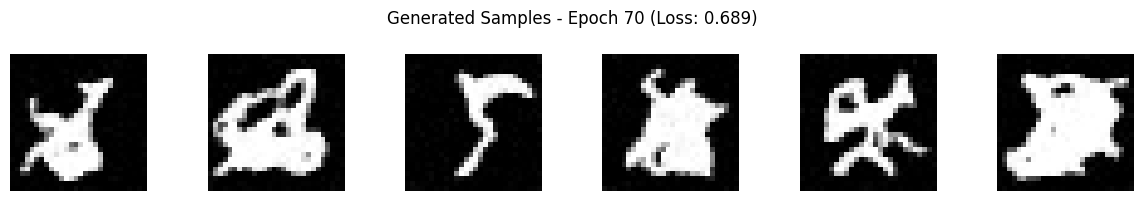

Epoch 71/100: 100%|██████████| 46/46 [00:01<00:00, 33.04it/s, loss=0.6748]


Epoch 71: Loss = 0.6832, LR = 0.000020


Epoch 72/100: 100%|██████████| 46/46 [00:01<00:00, 33.27it/s, loss=0.6451]


Epoch 72: Loss = 0.6800, LR = 0.000019


Epoch 73/100: 100%|██████████| 46/46 [00:01<00:00, 33.74it/s, loss=0.6306]


...

Epoch 78: Loss = 0.6829, LR = 0.000012


Epoch 79/100: 100%|██████████| 46/46 [00:01<00:00, 32.82it/s, loss=0.6570]


Epoch 79: Loss = 0.6784, LR = 0.000011


Epoch 80/100: 100%|██████████| 46/46 [00:01<00:00, 32.75it/s, loss=0.6505]


Epoch 80: Loss = 0.6800, LR = 0.000010
Generating samples...
 Step 1/1000, t=1.0000, noise SD=1.00
 Step 200/1000, t=0.8008, noise SD=0.98
 Step 400/1000, t=0.6006, noise SD=0.92
 Step 600/1000, t=0.4004, noise SD=0.75
 Step 800/1000, t=0.2002, noise SD=0.44


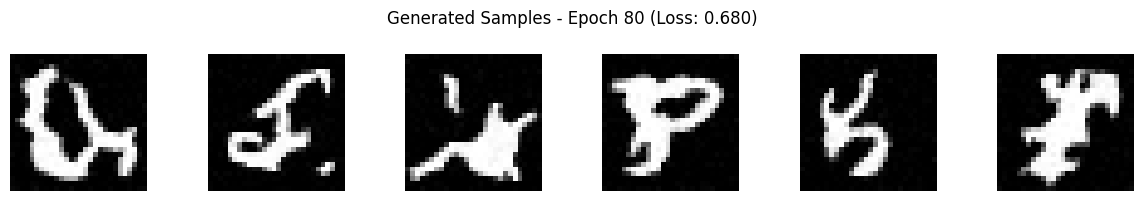

Epoch 81/100: 100%|██████████| 46/46 [00:01<00:00, 33.17it/s, loss=0.5666]


Epoch 81: Loss = 0.6832, LR = 0.000010


Epoch 82/100: 100%|██████████| 46/46 [00:01<00:00, 33.97it/s, loss=0.6696]


Epoch 82: Loss = 0.6842, LR = 0.000009


Epoch 83/100: 100%|██████████| 46/46 [00:01<00:00, 33.88it/s, loss=0.6591]


...

Epoch 88: Loss = 0.6762, LR = 0.000004


Epoch 89/100: 100%|██████████| 46/46 [00:01<00:00, 33.43it/s, loss=0.7083]


Epoch 89: Loss = 0.6849, LR = 0.000004


Epoch 90/100: 100%|██████████| 46/46 [00:01<00:00, 33.70it/s, loss=0.6880]


Epoch 90: Loss = 0.6725, LR = 0.000003
Generating samples...
 Step 1/1000, t=1.0000, noise SD=1.00
 Step 200/1000, t=0.8008, noise SD=0.98
 Step 400/1000, t=0.6006, noise SD=0.92
 Step 600/1000, t=0.4004, noise SD=0.75
 Step 800/1000, t=0.2002, noise SD=0.44


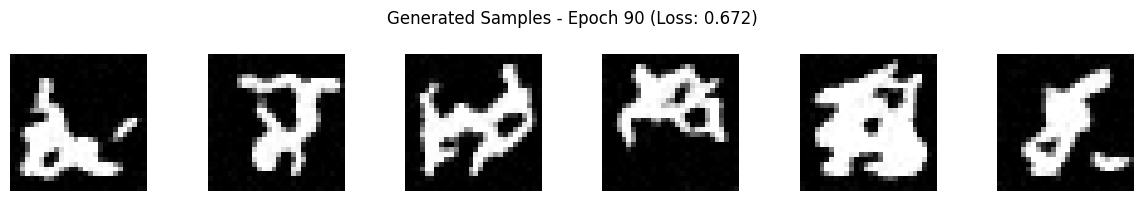

Epoch 91/100: 100%|██████████| 46/46 [00:01<00:00, 33.26it/s, loss=0.6708]


Epoch 91: Loss = 0.6781, LR = 0.000003


Epoch 92/100: 100%|██████████| 46/46 [00:01<00:00, 33.11it/s, loss=0.6028]


Epoch 92: Loss = 0.6874, LR = 0.000003


Epoch 93/100: 100%|██████████| 46/46 [00:01<00:00, 33.63it/s, loss=0.6551]


...

Epoch 98: Loss = 0.6835, LR = 0.000001


Epoch 99/100: 100%|██████████| 46/46 [00:01<00:00, 33.94it/s, loss=0.7091]


Epoch 99: Loss = 0.6839, LR = 0.000001


Epoch 100/100: 100%|██████████| 46/46 [00:01<00:00, 33.51it/s, loss=0.7757]


Epoch 100: Loss = 0.6778, LR = 0.000001
Generating samples...
 Step 1/1000, t=1.0000, noise SD=1.00
 Step 200/1000, t=0.8008, noise SD=0.98
 Step 400/1000, t=0.6006, noise SD=0.92
 Step 600/1000, t=0.4004, noise SD=0.75
 Step 800/1000, t=0.2002, noise SD=0.44


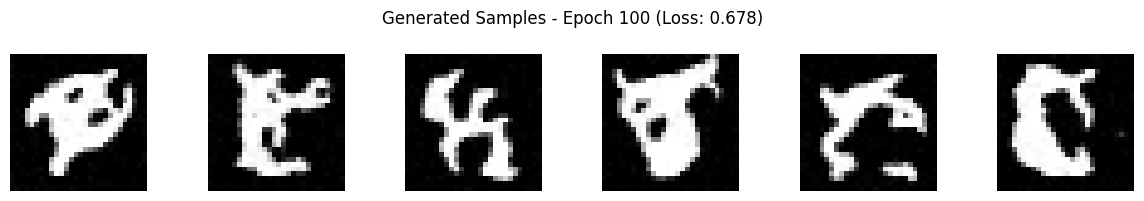

Checkpoint saved: dsm_model_epoch_100.pt


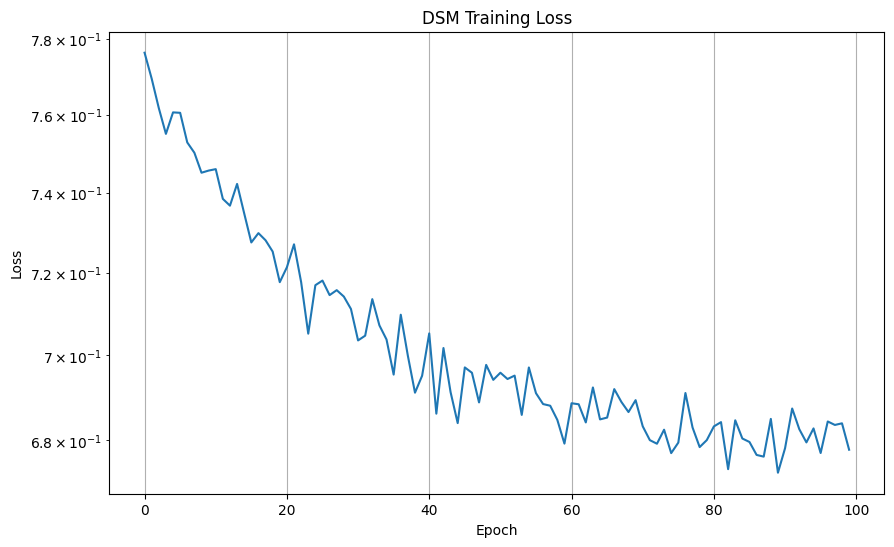

(ScoreNet(
   (convs): ModuleList(
     (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (4): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (5): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (6): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (7): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   )
   (bns): ModuleList(
     (0): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (3): BatchNorm2d(256, eps=1e-05, momentum=0.1, aff

In [ ]:
train_score_model(model, train_loader, device, num_epochs = 100)

### Question: _What do you observe as the training progresses?_

loss is steadily decreasing during the 100 training epoches, but slows down after 40 epoches.